<a href="https://colab.research.google.com/github/adrygarcia04/Math-BSc/blob/main/Simular_GP's.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SIMULACIÓN DE PROCESOS GAUSSIANOS**

**Autor**: Adrián García Barragán\
**Fecha**: 26/03/2026

## **1. Introducción**

Esta *Jupyter Notebook* en Google Colab se desarrolla en el seno de la asignatura «Procesos Estocásticos», una asignatura optativa del Grado en Matemáticas por la Universidad de Granada. El planteamiento para el curso 2025/2026 de esta asignatura, tiene como uno de sus objetivos transversales desarrollar competencias complementarias a las adquiridas en dicha titulación tales como el lenguaje de programación Python y algunas de sus librerías más útiles para la ciencia de datos y modelización (por ejemplo: *NumPy*, *Matplotlib*, ...).

Concretamente, este archivo es un ejercicio entregable que consiste en realizar simulaciones de trayectorias de distintos Procesos Gaussianos (GP's), usando algunas de las herramientas más habituales de _machine learning_.

---

In [47]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## **2. Muestras de una normal multivariante**

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, la primera tarea es entender cómo hacer esto.

En la siguiente celda se obtienen 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utilizo la función `np.random.multivariate_normal`.

Además, visualizo las muestras obtenidas, así como la dimensión de la matriz de muestras para cerciorarme de que todo se ha ejecutado debidamente.

In [48]:
vector_medias=np.zeros(3)
matriz_covarianzas=np.eye(3)
num_samples=50
samples=np.random.multivariate_normal(vector_medias, matriz_covarianzas,num_samples)

print("Dimensión: ", samples.shape)
print("Muestras: ")
print(samples)

Dimensión:  (50, 3)
Muestras: 
[[-1.57169676e-01  1.33825808e+00  1.02398346e+00]
 [-6.20759065e-01  2.95521056e-01  2.66820123e-01]
 [-1.02261946e-01 -1.12131864e+00  2.15258804e+00]
 [ 1.75946735e-01 -2.20373405e+00 -6.53782818e-01]
 [ 9.42894736e-01  6.66032079e-01  3.60286786e-01]
 [-3.90494255e-01  9.40852522e-01 -8.39971255e-01]
 [ 4.92456798e-01 -9.11185239e-01 -6.93928932e-02]
 [ 1.84714206e-02 -9.84035413e-01  1.48070573e+00]
 [ 1.62470207e+00  1.46846579e+00  2.44154956e+00]
 [ 6.84707909e-01  3.95066225e-01  1.53979489e+00]
 [ 1.27703127e-01  8.31694048e-01  8.04374658e-01]
 [ 1.99534343e+00 -2.91333555e-03  6.83554166e-01]
 [-2.25420127e-01 -4.24954422e-01  1.09328977e+00]
 [ 3.64120948e-01 -1.85454447e-01  5.97898160e-02]
 [ 2.52856742e-01 -1.32893336e+00  1.84962085e-01]
 [-1.28725471e-01 -1.98882925e-01 -3.89424960e-01]
 [-2.11447485e+00  9.24306086e-01  2.80127801e+00]
 [-9.87502027e-01  3.37296133e-01  4.11708557e-02]
 [-4.52212894e-01  5.31093344e-01 -7.60367006e-01]


Ahora hago lo mismo pero para una normal con matriz de covarianzas que no sea tan trivial como la identidad, por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$


In [49]:
vector_medias=np.zeros(3)
matriz_covarianzas=np.diag([1,10,100])
num_samples=50
samples=np.random.multivariate_normal(vector_medias, matriz_covarianzas,num_samples)

print("Dimensión: ", samples.shape)
print("Muestras: ")
print(samples)

Dimensión:  (50, 3)
Muestras: 
[[  0.51485007   5.13800954  -3.18778222]
 [ -1.37584327   0.67700712   4.14384036]
 [  0.90882326  -4.51638531  13.33286051]
 [ -0.50104769   4.49413439   0.35811879]
 [ -0.06358254   2.68466123  -8.73565677]
 [ -0.81492399  -3.19546937  -5.92003433]
 [ -0.49792438  -2.0848852   22.81447277]
 [  1.78388357  -0.21027491  -3.00138259]
 [ -0.21501593   0.59570952 -12.78058126]
 [  1.68388419   5.08517844  -9.16726744]
 [ -0.0726508   -3.70567124  22.09501729]
 [ -0.31441996   0.8661688   22.4748019 ]
 [  0.42941996   1.34337561 -11.73979844]
 [  0.36010189   3.92956404   5.26891633]
 [ -0.8893495   -4.27055795  -1.01033668]
 [  0.14200999  -5.80174538  -9.51274   ]
 [ -0.75965451   1.9440375   -0.30194367]
 [  1.66840327  -5.64320168   2.03979133]
 [  0.29914255   0.39167706  -1.8571418 ]
 [ -1.2489318    2.96781439   3.90065878]
 [  0.17040585  -2.41812412   7.089372  ]
 [  0.275515    -2.10122343   8.65790875]
 [  0.18878307  -7.59996413 -15.72110036]
 [ 

Tal y como cabía esperar, los valores de la primera componente de cada muestra se quedan más cercanos a cero, mientras que los de la segunda componente ... y los de la tercera más aún.

---

## **3. Simular un GP con kernel RBF**

Esta sección está dedicada a definir una función `simular_GP_RBF` que permita simular de un GP con kernel RBF. A continuación la usaré para generar los gráficos correspondientes, para los que fijaré la función de medias constantemente igual a cero.

En el punto 6 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función). Todo ello requerirá del concepto de _clases_.

Defino la función principal:

In [50]:
def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simular un GP con kernel RBF.

  INPUT:
    t (numpy.ndarry (n,)): vector de localizaciones en los que se quiere simular el GP.
    sigma_sq (float): varianza del kernel.
    lengthscale (float): parámetro de escala del kernel.
    num_samples (int): número de muestras a generar.

  OUTPUT:
    samples (numpy.ndarry (num_samples, len(t))): muestras del GP.
    !!! Devolverá error en los siguientes supuestos:
      1. Si el parámetro «sigma_sq» no mayor que 0.
      2. Si el parámetro «lengthscale» no es mayor que 0.
      3. Si el parámetro «num_samples» es menor que 1.
  """

  if not (sigma_sq>0):
    raise ValueError("El parámetro «sigma_sq» no es estríctamente positivo")

  if not (lengthscale>0):
    raise ValueError("El parámetro «lengthscale» no es estríctamente positivo")

  if (num_samples<1):
    raise ValueError("El número de muestras («num_samples») es menor que 1")

  vector_medias=np.zeros_like(t) #Calculo el vector de medias para que sea del tamaño correspondiente.

  matriz_dist=t.reshape(len(t),1)-t.reshape(1,len(t)) #Calculo la matriz de distancias que me servirá para calcular la matriz de covarianzas.
  matriz_covs=sigma_sq*np.exp((-1/2)*(matriz_dist/lengthscale)**2) #Calculo la matriz de covarianzas.

  samples=np.random.multivariate_normal(vector_medias,matriz_covs,size=num_samples) #Obtengo las muestras del GP.

  return samples

Ahora utilizo esta función para generar representaciones similares a las de las diapositivas 59 y 62. Al no definir una semilla concreta, realizo las simulaciones en celdas de código separadas a la de las representaciones para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [51]:
t=np.linspace(0,5,1000)

muestra0=simular_GP_RBF(t,0.25**2,1,10)
muestra1=simular_GP_RBF(t,1,1,10)
muestra2=simular_GP_RBF(t,4**2,1,10)

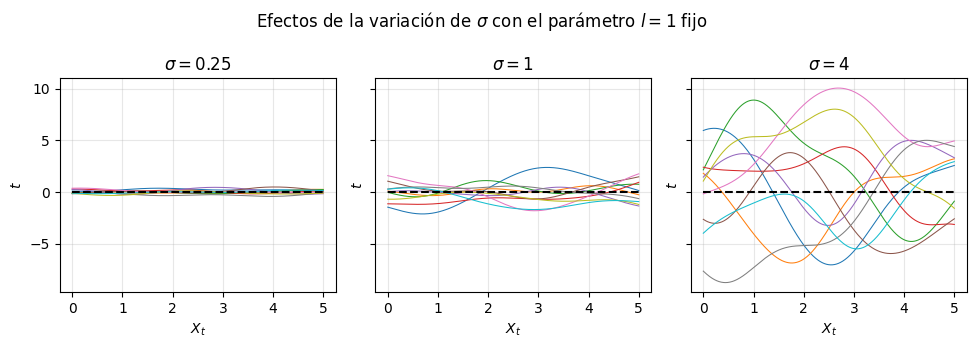

In [52]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 59
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(10, 3.5)) #Defino la cantidad de subgráficos (1 fila y 3 columnas), impongo que compartan el eje de ordenadas y fijo el tamaño total.

fig.suptitle(r"Efectos de la variación de $\sigma$ con el parámetro $l=1$ fijo")

for i in range(muestra0.shape[0]):
  axes[0].plot(t,muestra0[i,:],linewidth=0.75) #Primer subgráfico. Tengo que recurrir a un bucle para pintar cada una de las muestras para que se me queden en el intervalo [0,5].
axes[0].plot(t,0*t,"k--") #Represento la media en el primer subgráfico.
axes[0].set_title(r"$\sigma=0.25$") #Título del primer subgráfico.
axes[0].set_xlabel("$X_t$") #Etiqueta al eje x del primer subgráfico.
axes[0].set_ylabel("$t$") #Etiqueta al eje y del primer subgráfico.
axes[0].grid(True, alpha=0.3) #Pongo cuadrículo con una opacidad al 30% en el primer subgráfico.

for i in range(muestra1.shape[0]):
  axes[1].plot(t,muestra1[i,:],linewidth=0.75)
axes[1].plot(t,0*t,"k--")
axes[1].set_title(r"$\sigma=1$")
axes[1].set_xlabel("$X_t$")
axes[1].set_ylabel("$t$")
axes[1].grid(True, alpha=0.3)

for i in range(muestra2.shape[0]):
  axes[2].plot(t,muestra2[i,:],linewidth=0.75) #Primer subgráfico.
axes[2].plot(t,0*t,"k--")
axes[2].set_title(r"$\sigma=4$")
axes[2].set_xlabel("$X_t$")
axes[2].set_ylabel("$t$")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()  #Ajusto el espaciado

plt.show()

In [53]:
t=np.linspace(0,5,1000)

muestra0=simular_GP_RBF(t,1,0.25,10)
muestra1=simular_GP_RBF(t,1,1,10)
muestra2=simular_GP_RBF(t,1,4,10)

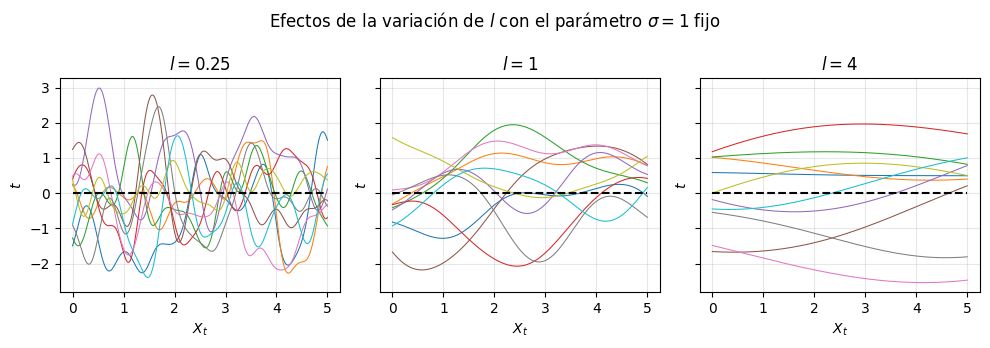

In [54]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 62
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(10, 3.5)) #Defino la cantidad de subgráficos (1 fila y 3 columnas), impongo que compartan el eje de ordenadas y fijo el tamaño total.

fig.suptitle(r"Efectos de la variación de $l$ con el parámetro $\sigma=1$ fijo")

for i in range(muestra0.shape[0]):
  axes[0].plot(t,muestra0[i,:],linewidth=0.75) #Primer subgráfico. Tengo que recurrir a un bucle para pintar cada una de las muestras para que se me queden en el intervalo [0,5].
axes[0].plot(t,0*t,"k--") #Represento la media en el primer subgráfico.
axes[0].set_title(r"$l=0.25$") #Título del primer subgráfico.
axes[0].set_xlabel("$X_t$") #Etiqueta al eje x del primer subgráfico.
axes[0].set_ylabel("$t$") #Etiqueta al eje y del primer subgráfico.
axes[0].grid(True, alpha=0.3) #Pongo cuadrículo con una opacidad al 30% en el primer subgráfico.

for i in range(muestra1.shape[0]):
  axes[1].plot(t,muestra1[i,:],linewidth=0.75)
axes[1].plot(t,0*t,"k--")
axes[1].set_title(r"$l=1$")
axes[1].set_xlabel("$X_t$")
axes[1].set_ylabel("$t$")
axes[1].grid(True, alpha=0.3)

for i in range(muestra2.shape[0]):
  axes[2].plot(t,muestra2[i,:],linewidth=0.75)
axes[2].plot(t,0*t,"k--")
axes[2].set_title(r"$l=4$")
axes[2].set_xlabel("$X_t$")
axes[2].set_ylabel("$t$")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()  #Ajusto el espaciado

plt.show()

---

## **4. Simular un GP con kernel periódico**
En esta sección voy a definir la función `simular_GP_periodic` que permita simular de un GP con kernel periódico. Posteriormente la use para generar imágenes similares a las de las diapositivas. Supondré función de medias constantemente igual a cero.

In [55]:
def simular_GP_periodic(t, sigma_sq=1, lengthscale=1, period=1, num_samples=1):
  """
  Simular un GP con kernel periódico.

  INPUT:
    t (numpy.ndarry (n,)): vector de localizaciones en los que se quiere simular el GP.
    sigma_sq (float): varianza del kernel.
    lengthscale (float): parámetro de escala del kernel.
    period (float): parámetro de periodo del kernel.
    num_samples (float): número de muestras a generar.

  OUTPUT:
    samples (numpy.ndarry (num_samples, len(t))): muestras del GP.
      !!! Devolverá error en los siguientes supuestos:
      1. Si el parámetro «sigma_sq» no mayor que 0.
      2. Si el parámetro «lengthscale» no es mayor que 0.
      3. Si el parámetro «period» no es mayor que 0.
      4. Si el parámetro «num_samples» es menor que 1.
  """

  if not (sigma_sq>0):
    raise ValueError(r"El parámetro «sigma_sq» no es estríctamente positivo")

  if not (lengthscale>0):
    raise ValueError("El parámetro «lengthscale» no es estríctamente positivo")

  if not (period>0):
    raise ValueError("El parámetro «period» no es estríctamente positivo")

  if (num_samples<1):
    raise ValueError("El número de muestras («num_samples») es menor que 1")

  vector_medias=np.zeros_like(t) #Calculo el vector de medias para que sea del tamaño correspondiente.

  matriz_dist=t.reshape(len(t),1)-t.reshape(1,len(t)) #Calculo la matriz de distancias que me servirá para calcular la matriz de covarianzas.
  matriz_covs=sigma_sq*np.exp((-2/lengthscale**2)*(np.sin(np.pi*matriz_dist/period))**2) #Calculo la matriz de covarianzas.

  samples=np.random.multivariate_normal(vector_medias,matriz_covs,size=num_samples) #Obtengo las muestras del GP.

  return samples

Ahora utilizo esta función para generar representaciones similares a las de las diapositivas 72, 74 y 76. Al no definir una semilla concreta, realizo las simulaciones en celdas de código separadas a la de las representaciones para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [56]:
t=np.linspace(0,5,1000)

muestra0=simular_GP_periodic(t,lengthscale=0.25,num_samples=2)
muestra1=simular_GP_periodic(t,lengthscale=4,num_samples=2)

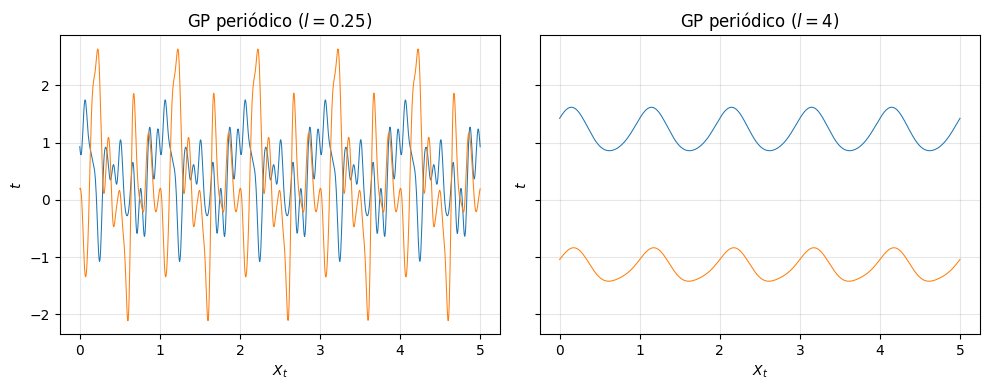

In [57]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 72
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4)) #Defino la cantidad de subgráficos (1 fila y 2 columnas), impongo que compartan el eje de ordenadas y fijo el tamaño total.

for i in range(muestra0.shape[0]):
  axes[0].plot(t,muestra0[i,:],linewidth=0.75) #Primer subgráfico. Tengo que recurrir a un bucle para pintar cada una de las muestras para que se me queden en el intervalo [0,5].
axes[0].set_title(r"GP periódico ($l=0.25$)") #Título del primer subgráfico.
axes[0].set_xlabel("$X_t$") #Etiqueta al eje x del primer subgráfico.
axes[0].set_ylabel("$t$") #Etiqueta al eje y del primer subgráfico.
axes[0].grid(True, alpha=0.3) #Pongo cuadrículo con una opacidad al 30% en el primer subgráfico.

for i in range(muestra1.shape[0]):
  axes[1].plot(t,muestra1[i,:],linewidth=0.75)
axes[1].set_title(r"GP periódico ($l=4$)")
axes[1].set_xlabel("$X_t$")
axes[1].set_ylabel("$t$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()  #Ajusto el espaciado

plt.show()

In [58]:
t=np.linspace(0,5,1000)

muestra0=simular_GP_periodic(t,period=1,num_samples=2)
muestra1=simular_GP_periodic(t,period=2.5,num_samples=2)

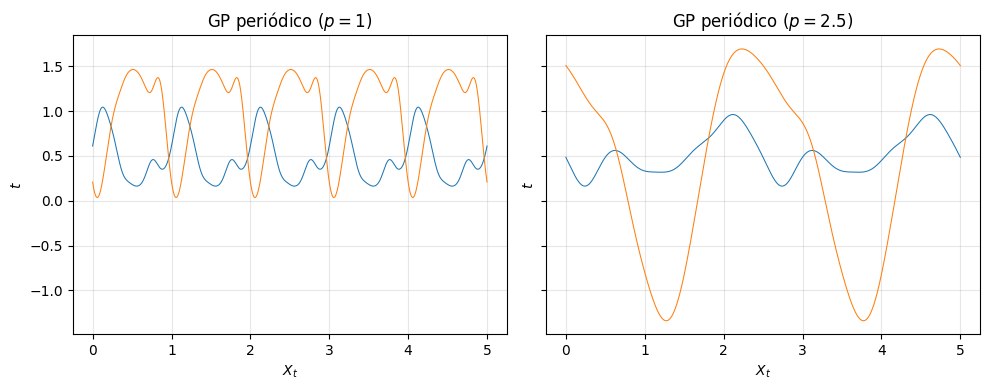

In [59]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 74
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4)) #Defino la cantidad de subgráficos (1 fila y 2 columnas), impongo que compartan el eje de ordenadas y fijo el tamaño total.

for i in range(muestra0.shape[0]):
  axes[0].plot(t,muestra0[i,:],linewidth=0.75) #Primer subgráfico. Tengo que recurrir a un bucle para pintar cada una de las muestras para que se me queden en el intervalo [0,5].
axes[0].set_title(r"GP periódico ($p=1$)") #Título del primer subgráfico.
axes[0].set_xlabel("$X_t$") #Etiqueta al eje x del primer subgráfico.
axes[0].set_ylabel("$t$") #Etiqueta al eje y del primer subgráfico.
axes[0].grid(True, alpha=0.3) #Pongo cuadrículo con una opacidad al 30% en el primer subgráfico.

for i in range(muestra1.shape[0]):
  axes[1].plot(t,muestra1[i,:],linewidth=0.75)
axes[1].set_title(r"GP periódico ($p=2.5$)")
axes[1].set_xlabel("$X_t$")
axes[1].set_ylabel("$t$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()  #Ajusto el espaciado

plt.show()

In [60]:
t=np.linspace(0,5,1000)

muestra0=simular_GP_periodic(t,num_samples=2)
muestra1=simular_GP_periodic(t,sigma_sq=4**2,num_samples=2)

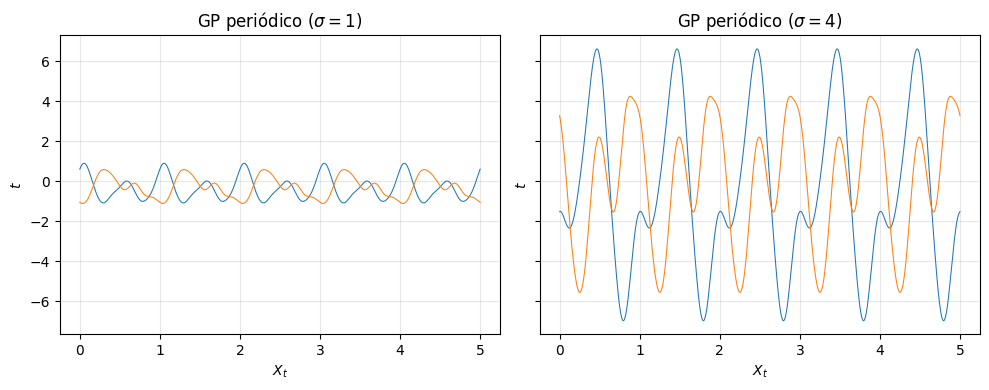

In [61]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 76
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4)) #Defino la cantidad de subgráficos (1 fila y 2 columnas), impongo que compartan el eje de ordenadas y fijo el tamaño total.

for i in range(muestra0.shape[0]):
  axes[0].plot(t,muestra0[i,:],linewidth=0.75) #Primer subgráfico. Tengo que recurrir a un bucle para pintar cada una de las muestras para que se me queden en el intervalo [0,5].
axes[0].set_title(r"GP periódico ($\sigma=1$)") #Título del primer subgráfico.
axes[0].set_xlabel("$X_t$") #Etiqueta al eje x del primer subgráfico.
axes[0].set_ylabel("$t$") #Etiqueta al eje y del primer subgráfico.
axes[0].grid(True, alpha=0.3) #Pongo cuadrículo con una opacidad al 30% en el primer subgráfico.

for i in range(muestra1.shape[0]):
  axes[1].plot(t,muestra1[i,:],linewidth=0.75)
axes[1].set_title(r"GP periódico ($\sigma=4$)")
axes[1].set_xlabel("$X_t$")
axes[1].set_ylabel("$t$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()  #Ajusto el espaciado

plt.show()

---

## **5. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m \in \mathbb{N}$)**

En esta sección voy a definir una función `simular_GP_DPKpoly` que permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, …, $t^m$. Posteriormente la usaré para generar imágenes similares a las de las diapositivas. Supondré función de medias constantemente igual a cero.

In [62]:
def simular_GP_DPKpoly(t, m=1, num_samples=1):
    """
    Simular un GP con kernel DPK con funciones base 1, t, ..., t^m.

    INPUT:
      t (n,): vector de localizaciones en los que se quiere simular el GP.
      m (int): grado máximo de los monomios utilizados.
      num_samples (int): número de muestras a generar.

    OUTPUT:
      samples (numpy.ndarry (num_samples, len(t))): muestras del GP.
        !!! Devolverá error en los siguientes supuestos:
          1. Si el parámetro «num_samples» es menor que 1.
          2. Si el parámetro «m» es menor que 1.
    """

    if (num_samples<1):
      raise ValueError("El número de muestras («num_samples») es menor que 1")

    if (m<1):
     raise ValueError("El parámetro «m» es menor que 1")

    vector_medias=np.zeros_like(t) #Calculo el vector de medias para que sea del tamaño correspondiente.

    matriz_aux=np.vander(t,N=m+1,increasing=True) #Defino una matriz auxiliar con np.vander() porque, en última instancia, lo que necesito es una matriz de Vandermonde. (También podría haber hecho t[:,None]**np.arange(n) )
    matriz_covs=matriz_aux@np.transpose(matriz_aux) #Defino la matriz de covarianzas como producto de la matriz auxiliar por su transpuesta, en virtud de lo visto en el diapositiva 82.
    matriz_covs=matriz_covs+1e-9*np.eye(len(t)) #Sumo un "jitter" (ruido definido positivo) para asegurar que por problmeas numéricos de redondeo la matriz no va dejar de ser semidefinida positiva.

    samples=np.random.multivariate_normal(vector_medias,matriz_covs,size=num_samples) #Obtengo las muestras del GP.

    return samples

Ahora utilizo esta función para generar representaciones similares a la de la diapositiva 89. Al no definir una semilla concreta, realizo las simulaciones en celdas de código separadas a la de las representaciones para no recalcular la muestra cada vez que modifique algo de los gráficos.

In [63]:
t=np.linspace(-10,10,1000)

muestra0=simular_GP_DPKpoly(t,num_samples=5)
muestra1=simular_GP_DPKpoly(t,2,5)
muestra2=simular_GP_DPKpoly(t,3,5)

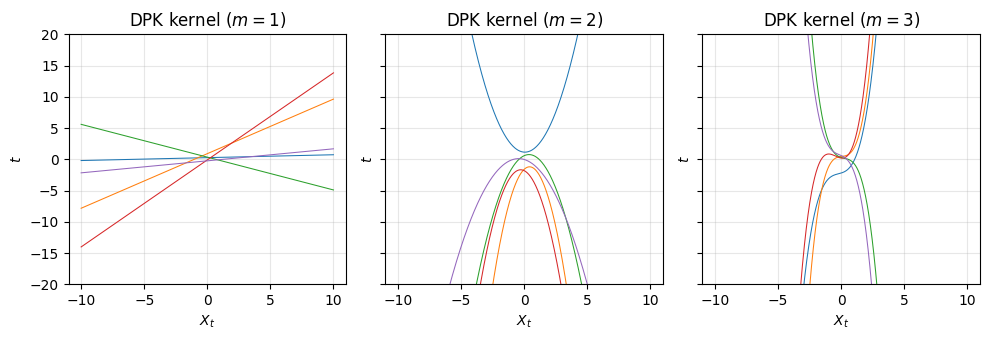

In [64]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 89
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(10, 3.5)) #Defino la cantidad de subgráficos (1 fila y 3 columnas), impongo que compartan el eje de ordenadas y fijo el tamaño total.

for i in range(muestra0.shape[0]):
  axes[0].plot(t,muestra0[i,:],linewidth=0.75) #Primer subgráfico. Tengo que recurrir a un bucle para pintar cada una de las muestras para que se me queden en el intervalo [0,5].
axes[0].set_ylim(-20, 20)
axes[0].set_title(r"DPK kernel ($m=1$)") #Título del primer subgráfico.
axes[0].set_xlabel("$X_t$") #Etiqueta al eje x del primer subgráfico.
axes[0].set_ylabel("$t$") #Etiqueta al eje y del primer subgráfico.
axes[0].grid(True, alpha=0.3) #Pongo cuadrículo con una opacidad al 30% en el primer subgráfico.

for i in range(muestra1.shape[0]):
  axes[1].plot(t,muestra1[i,:],linewidth=0.75)
axes[1].set_title(r"DPK kernel ($m=2$)")
axes[1].set_xlabel("$X_t$")
axes[1].set_ylabel("$t$")
axes[1].grid(True, alpha=0.3)

for i in range(muestra2.shape[0]):
  axes[2].plot(t,muestra2[i,:],linewidth=0.75)
axes[2].set_title(r"DPK kernel ($m=3$)")
axes[2].set_xlabel("$X_t$")
axes[2].set_ylabel("$t$")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()  #Ajusto el espaciado

plt.show()

---

## **6. ¿Cómo hacer que el kernel se pase como parámetro?¿y la función de medias?**

Estas preguntas, bastante generales, se pueden abordar de muchas maneras. En esta sección se presenta muy brevemente una solución basada en el paradigma de programación orientada a objetos (POO). Es la manera más habitual de programar en Python y en muchos otros lenguajes.

La idea de la POO es estructurar el código usando el concepto de clase. Concretamente, una clase es una estructura que nos permite crear objetos que contienen dos cosas principalmente:

Atributos: valores que forman parte del objeto.
Métodos: acciones que puede realizar el objeto.
A continuación definimos una clase para describir el kernel RBF. La clase define dos atributos:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación defino una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.




In [65]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

En la celda anterior simplemente hemos definido "qué es un objeto de tipo RBF".

En la celda siguiente, utilizo la clase recién definida para crear un objeto concreto de ese tipo:

In [66]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__ (es un método especial que se utiliza de esta manera)
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

<class '__main__.RBF'>
(100, 100)


A continuación defino una clase para la función de medias constantemente igual a cero:

In [67]:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

Y creo un objeto de ese tipo:

In [68]:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

<class '__main__.Zero_Mean_Function'>
(100,)
True


Defino ahora una función ```simular_GP``` que recibe como parámetros **cualquier función de medias** (```mf```) y **cualquier kernel** (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [69]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para validar esta función, genero la imagen de la diapositiva 64, donde se usaba la función de medias identidad y el kernel RBF.

Para ello, defino una clase para la función de medias identidad:

In [70]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, uso esta clase, la clase RBF, y la función `simular_GP` para obtener lo buscado:

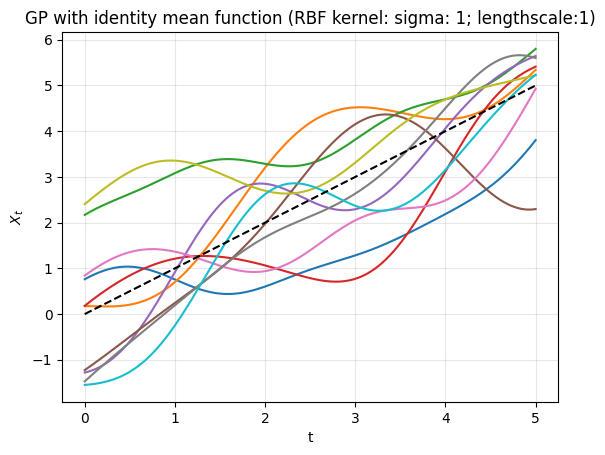

In [74]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: sigma: {sigma}; lengthscale:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()